# Final Evaluation — One-Week-Ahead Dengue Case Forecasting

This notebook performs the **single final evaluation** on the previously untouched 2021–2023 future holdout.

All development decisions are treated as frozen before this notebook is run.

## Forecasting scope

- **Outcome:** weekly dengue case count
- **Forecast horizon:** one week ahead
- **Prediction timing:** use information available through week `t-1` to predict week `t`
- **Weekly convention:** Sunday–Saturday, identified by Sunday `week_start_date`

## Frozen model specifications

1. **Persistence** — naïve benchmark: predict week `t` using `dengue_cases_lag1`
2. **SARIMA_1** — `(1,0,0) × (1,0,0,52)`
3. **XGB_3 history-only** — primary ML model
4. **XGB_3 history + climate** — direct climate-comparison model

## Final evaluation procedure

- Refit selected model specifications using all information available through **31 December 2020**
- Evaluate once on **2021–2023**
- Report:
  - MAE (primary metric)
  - RMSE
  - R²
  - higher-incidence-week error
  - actual-vs-predicted plots
- Do not alter model specifications after seeing final test performance

## 1. Setup and data loading

Input:

`data/processed/modelling/maynas_dengue_features_1w_ahead.csv`

All exported outputs use repository-relative paths only.

In [22]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

try:
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    STATSMODELS_AVAILABLE = True
except ImportError:
    STATSMODELS_AVAILABLE = False

warnings.filterwarnings(
    "ignore",
    message="Non-stationary starting autoregressive parameters"
)
warnings.filterwarnings(
    "ignore",
    message="Non-invertible starting MA parameters"
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 170)

PROJECT_ROOT = Path.cwd().resolve().parent

DATA_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "modelling"
    / "maynas_dengue_features_1w_ahead.csv"
)

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "final"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_FILE)

df["week_start_date"] = pd.to_datetime(
    df["week_start_date"],
    errors="raise"
)

df = (
    df
    .sort_values("week_start_date")
    .reset_index(drop=True)
)

print(f"Rows: {len(df):,}")
print(f"XGBoost available: {XGBOOST_AVAILABLE}")
print(f"Statsmodels available: {STATSMODELS_AVAILABLE}")

Rows: 1,248
XGBoost available: True
Statsmodels available: True


## 2. Freeze final train and test periods

All observed data through the end of 2020 are now available for refitting.

- **Refit period:** 2000–2020
- **Final test:** 2021–2023

In [23]:
REFIT_END = pd.Timestamp("2020-12-31")
TEST_START = pd.Timestamp("2021-01-01")
TEST_END = pd.Timestamp("2023-12-31")

refit_df = df.loc[
    df["week_start_date"] <= REFIT_END
].copy()

test_df = df.loc[
    (df["week_start_date"] >= TEST_START)
    & (df["week_start_date"] <= TEST_END)
].copy()

split_summary = pd.DataFrame({
    "period": ["refit", "final_test"],
    "rows": [len(refit_df), len(test_df)],
    "first_week": [
        refit_df["week_start_date"].min(),
        test_df["week_start_date"].min(),
    ],
    "last_week": [
        refit_df["week_start_date"].max(),
        test_df["week_start_date"].max(),
    ],
    "mean_cases": [
        refit_df["dengue_cases"].mean(),
        test_df["dengue_cases"].mean(),
    ],
    "median_cases": [
        refit_df["dengue_cases"].median(),
        test_df["dengue_cases"].median(),
    ],
    "max_cases": [
        refit_df["dengue_cases"].max(),
        test_df["dengue_cases"].max(),
    ],
})

split_summary

,period,rows,first_week,last_week,mean_cases,median_cases,max_cases
0,refit,1092,2000-01-02,2020-12-27,57.665751,21.5,2941.0
1,final_test,156,2021-01-03,2023-12-24,37.108974,15.0,362.0


### Interpretation — refit and final-test periods

The refit dataset contains **1,092 observed dengue weeks** through the end of 2020, while the untouched final test contains **156 weeks** from 2021–2023.

The test period has a lower average burden than the refit period:

- refit mean: **57.67 cases**
- final-test mean: **37.11 cases**
- refit median: **21.5 cases**
- final-test median: **15 cases**

The final test still contains substantial variation, including a maximum of **362 cases**, so it provides a meaningful future holdout rather than an entirely quiet period.

Because this test period was not used during feature selection, model selection or hyperparameter tuning, its results should be treated as the definitive out-of-sample evaluation.


### Interpretation — final holdout design

The final test period is now opened only after all model choices have been frozen.

No validation-driven tuning should occur from this point onward. The 2021–2023 results are therefore treated as the final estimate of out-of-sample performance under the selected forecasting design.

## 3. Metrics

In [24]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

def clip_nonnegative(values):
    return np.clip(
        np.asarray(values, dtype=float),
        a_min=0,
        a_max=None,
    )

## 4. Final benchmark 1 — persistence

The persistence forecast remains:

`prediction(t) = dengue_cases_lag1`

In [25]:
persistence_test = test_df[
    [
        "week_start_date",
        "dengue_cases",
        "dengue_cases_lag1",
    ]
].dropna().copy()

persistence_test["prediction"] = (
    persistence_test["dengue_cases_lag1"]
)

persistence_test["residual"] = (
    persistence_test["dengue_cases"]
    - persistence_test["prediction"]
)

persistence_metrics = regression_metrics(
    persistence_test["dengue_cases"],
    persistence_test["prediction"],
)

pd.Series(
    persistence_metrics,
    name="Persistence"
)

MAE     11.217949
RMSE    22.001457
R2       0.844173
Name: Persistence, dtype: float64

### Interpretation — final persistence benchmark

Persistence achieves:

- **MAE: 11.22**
- **RMSE: 22.00**
- **R²: 0.844**

This remains a strong benchmark. The result again confirms that one-week-ahead dengue incidence is highly predictable from the immediately preceding week's case count.

Any more complex model should therefore be judged not only by whether it performs well in absolute terms, but by whether it materially improves on this simple autoregressive rule.


### Interpretation — role of persistence

Persistence remains the universal naïve benchmark for this project. Its final MAE of 11.22 is sufficiently strong that the winning model improves only slightly on typical weekly absolute error.

This is substantively important: the project demonstrates that recent dengue incidence itself carries most of the short-horizon forecasting signal.


## 5. Final XGBoost feature specifications

In [26]:
HISTORY_FEATURES = [
    "week_sin",
    "week_cos",
    "dengue_cases_lag1",
    "dengue_cases_lag2",
    "dengue_cases_lag4",
    "dengue_cases_lag8",
]

CLIMATE_FEATURES = [
    "precip_sum_mm_lag1",
    "precip_sum_mm_lag4",
    "precip_sum_mm_prev4w_sum",

    "temperature_c_mean_lag1",
    "temperature_c_mean_lag8",
    "temperature_c_mean_prev4w_mean",

    "specific_humidity_kgkg_mean_lag1",
    "relative_humidity_pct_mean_prev4w_mean",

    "wind_speed_ms_mean_lag1",
    "wind_speed_ms_mean_lag12",
    "wind_speed_ms_mean_prev4w_mean",

    "surface_pressure_hpa_mean_lag1",
    "surface_pressure_hpa_mean_lag8",
    "surface_pressure_hpa_mean_prev4w_mean",

    "ndvi_mean_weekly_lag1",
    "ndvi_mean_weekly_lag12",
    "ndvi_mean_weekly_prev4w_mean",
]

CLIMATE_ENHANCED_FEATURES = (
    HISTORY_FEATURES
    + CLIMATE_FEATURES
)

for feature in CLIMATE_ENHANCED_FEATURES:
    if feature not in df.columns:
        raise ValueError(
            f"Required frozen feature missing: {feature}"
        )

print(f"History-only features: {len(HISTORY_FEATURES)}")
print(
    f"History + climate features: "
    f"{len(CLIMATE_ENHANCED_FEATURES)}"
)

History-only features: 6
History + climate features: 23


## 6. Final XGBoost model configuration

The frozen `XGB_3` configuration is:

- `n_estimators = 300`
- `max_depth = 2`
- `learning_rate = 0.05`
- `subsample = 1.0`
- `colsample_bytree = 1.0`
- `objective = reg:squarederror`

No further tuning is performed.

In [27]:
if not XGBOOST_AVAILABLE:
    print(
        "XGBoost is not installed in this environment.\n"
        "Install it into dengue-venv with:\n\n"
        '& "$env:LOCALAPPDATA\\dengue-venv\\Scripts\\python.exe" '
        '-m pip install xgboost'
    )

In [28]:
def make_xgb3():
    return XGBRegressor(
        objective="reg:squarederror",
        n_estimators=300,
        max_depth=2,
        learning_rate=0.05,
        subsample=1.0,
        colsample_bytree=1.0,
        random_state=42,
        n_jobs=-1,
    )

## 7. Final XGBoost — history only

In [29]:
xgb_history_train = refit_df[
    ["week_start_date", "dengue_cases"]
    + HISTORY_FEATURES
].dropna().copy()

xgb_history_test = test_df[
    ["week_start_date", "dengue_cases"]
    + HISTORY_FEATURES
].dropna().copy()

xgb_history_model = make_xgb3()

xgb_history_model.fit(
    xgb_history_train[HISTORY_FEATURES],
    xgb_history_train["dengue_cases"],
)

xgb_history_test["prediction"] = (
    clip_nonnegative(
        xgb_history_model.predict(
            xgb_history_test[HISTORY_FEATURES]
        )
    )
)

xgb_history_test["residual"] = (
    xgb_history_test["dengue_cases"]
    - xgb_history_test["prediction"]
)

xgb_history_metrics = regression_metrics(
    xgb_history_test["dengue_cases"],
    xgb_history_test["prediction"],
)

pd.Series(
    xgb_history_metrics,
    name="XGB_3 history-only"
)

MAE     11.448120
RMSE    22.347470
R2       0.839233
Name: XGB_3 history-only, dtype: float64

### Interpretation — final history-only XGBoost

The frozen history-only `XGB_3` model achieves:

- **MAE: 11.45**
- **RMSE: 22.35**
- **R²: 0.839**

This is slightly worse than persistence on all three final-test metrics.

That differs from validation, where history-only XGBoost was the strongest model. The change in ranking is important and should be reported transparently. It illustrates why the untouched future holdout was necessary: validation performance did not perfectly predict future generalisation.

The result also reinforces how competitive simple persistence is for a highly autocorrelated weekly dengue series.


### Interpretation — development winner versus final holdout

History-only XGBoost was selected as the primary ML model during development, but the final holdout shows that its apparent validation advantage does not persist.

This result should be retained rather than corrected through additional tuning. It is evidence of genuine out-of-sample uncertainty and illustrates why model decisions were frozen before opening the test period.


## 8. Final XGBoost — history + climate

In [30]:
xgb_climate_train = refit_df[
    ["week_start_date", "dengue_cases"]
    + CLIMATE_ENHANCED_FEATURES
].dropna().copy()

xgb_climate_test = test_df[
    ["week_start_date", "dengue_cases"]
    + CLIMATE_ENHANCED_FEATURES
].dropna().copy()

xgb_climate_model = make_xgb3()

xgb_climate_model.fit(
    xgb_climate_train[
        CLIMATE_ENHANCED_FEATURES
    ],
    xgb_climate_train["dengue_cases"],
)

xgb_climate_test["prediction"] = (
    clip_nonnegative(
        xgb_climate_model.predict(
            xgb_climate_test[
                CLIMATE_ENHANCED_FEATURES
            ]
        )
    )
)

xgb_climate_test["residual"] = (
    xgb_climate_test["dengue_cases"]
    - xgb_climate_test["prediction"]
)

xgb_climate_metrics = regression_metrics(
    xgb_climate_test["dengue_cases"],
    xgb_climate_test["prediction"],
)

pd.Series(
    xgb_climate_metrics,
    name="XGB_3 history+climate"
)

MAE     11.132460
RMSE    21.218256
R2       0.855070
Name: XGB_3 history+climate, dtype: float64

### Interpretation — final climate-enhanced XGBoost

The frozen climate-enhanced `XGB_3` model achieves:

- **MAE: 11.13**
- **RMSE: 21.22**
- **R²: 0.855**

This is the strongest final-test performance across the frozen model set.

The result is particularly important because the climate-enhanced model did **not** win during validation. On the untouched 2021–2023 holdout, however, the additional environmental information improves both typical absolute error and larger-error performance.

This provides direct out-of-sample evidence that environmental predictors can add incremental forecasting value beyond recent dengue history and seasonality.


### Interpretation — direct climate comparison

The history-only and climate-enhanced XGBoost models have the same algorithm and frozen hyperparameters. Their difference is therefore specifically useful for evaluating whether the additional environmental features improve future prediction.

The actual final comparison is interpreted in Section 11 below.


## 9. Final SARIMA_1

The frozen traditional model is:

- non-seasonal order `(1, 0, 0)`
- seasonal order `(1, 0, 0, 52)`

The complete Sunday calendar is reconstructed so the four known historical dengue surveillance gaps remain missing rather than being treated as zero.

In [31]:
calendar = pd.date_range(
    start=df["week_start_date"].min(),
    end=df["week_start_date"].max(),
    freq="W-SUN"
)

weekly = (
    df
    .set_index("week_start_date")
    .reindex(calendar)
)

weekly.index.name = "week_start_date"

sarima_refit_endog = (
    weekly.loc[
        weekly.index <= REFIT_END,
        "dengue_cases",
    ]
    .astype(float)
)

sarima_test_endog = (
    weekly.loc[
        (weekly.index >= TEST_START)
        & (weekly.index <= TEST_END),
        "dengue_cases",
    ]
    .astype(float)
)

print(
    f"SARIMA refit calendar weeks: "
    f"{len(sarima_refit_endog):,}"
)
print(
    f"SARIMA final test weeks: "
    f"{len(sarima_test_endog):,}"
)

SARIMA refit calendar weeks: 1,096
SARIMA final test weeks: 156


In [32]:
def rolling_one_step_forecast(
    fitted_result,
    test_endog,
):
    predictions = []
    result = fitted_result

    endog_name = test_endog.name

    for date in test_endog.index:

        forecast = result.get_forecast(
            steps=1
        )

        prediction = float(
            np.asarray(
                forecast.predicted_mean
            ).reshape(-1)[0]
        )

        predictions.append(
            {
                "week_start_date": date,
                "prediction_raw": prediction,
            }
        )

        actual = test_endog.loc[date]

        new_endog = pd.Series(
            [actual],
            index=pd.DatetimeIndex([date]),
            name=endog_name,
            dtype=float,
        )

        result = result.append(
            endog=new_endog,
            refit=False,
        )

    prediction_df = pd.DataFrame(
        predictions
    )

    prediction_df["prediction"] = (
        clip_nonnegative(
            prediction_df["prediction_raw"]
        )
    )

    return prediction_df

In [33]:
if not STATSMODELS_AVAILABLE:
    print(
        "statsmodels is not installed in this environment.\n"
        "Install it into dengue-venv with:\n\n"
        '& "$env:LOCALAPPDATA\\dengue-venv\\Scripts\\python.exe" '
        '-m pip install statsmodels'
    )

In [34]:
sarima_final_model = SARIMAX(
    sarima_refit_endog,
    order=(1, 0, 0),
    seasonal_order=(1, 0, 0, 52),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False,
)

sarima_final_fitted = (
    sarima_final_model.fit(
        disp=False,
        maxiter=200,
    )
)

sarima_test = rolling_one_step_forecast(
    sarima_final_fitted,
    sarima_test_endog,
)

sarima_test["dengue_cases"] = (
    sarima_test_endog.values
)

sarima_test["residual"] = (
    sarima_test["dengue_cases"]
    - sarima_test["prediction"]
)

sarima_metrics = regression_metrics(
    sarima_test["dengue_cases"],
    sarima_test["prediction"],
)

pd.Series(
    sarima_metrics,
    name="SARIMA_1"
)

MAE     12.143967
RMSE    21.667084
R2       0.848873
Name: SARIMA_1, dtype: float64

### Interpretation — role of the traditional comparator

SARIMA_1 remains the frozen traditional time-series comparator. It is not the final winner, but its relatively strong RMSE confirms that a conventional autoregressive seasonal model remains credible for this forecasting problem.

This provides a meaningful basis for evaluating H2 rather than comparing machine learning only with a weak benchmark.


### Interpretation — role of the traditional comparator

SARIMA_1 remains the frozen traditional time-series comparator. It is not the final winner, but its relatively strong RMSE confirms that a conventional autoregressive seasonal model remains credible for this forecasting problem.

This provides a meaningful basis for evaluating H2 rather than comparing machine learning only with a weak benchmark.


## 10. Final model comparison

In [35]:
final_comparison = pd.DataFrame([
    {
        "model": "Persistence",
        **persistence_metrics,
        "test_rows": len(persistence_test),
    },
    {
        "model": "SARIMA_1",
        **sarima_metrics,
        "test_rows": len(sarima_test),
    },
    {
        "model": "XGB_3 history-only",
        **xgb_history_metrics,
        "test_rows": len(xgb_history_test),
    },
    {
        "model": "XGB_3 history+climate",
        **xgb_climate_metrics,
        "test_rows": len(xgb_climate_test),
    },
])

final_comparison = (
    final_comparison
    .sort_values("MAE")
    .reset_index(drop=True)
)

final_comparison

,model,MAE,RMSE,R2,test_rows
0,XGB_3 history+climate,11.132460,21.218256,0.855070,156
1,Persistence,11.217949,22.001457,0.844173,156
2,XGB_3 history-only,11.448120,22.347470,0.839233,156
3,SARIMA_1,12.143967,21.667084,0.848873,156


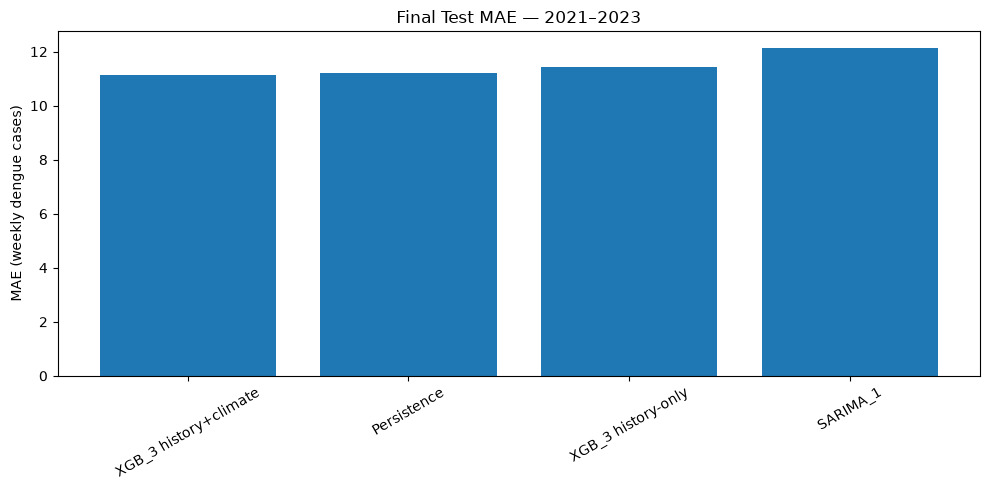

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    final_comparison["model"],
    final_comparison["MAE"]
)

ax.set_title(
    "Final Test MAE — 2021–2023"
)
ax.set_ylabel(
    "MAE (weekly dengue cases)"
)
ax.tick_params(
    axis="x",
    rotation=30
)

plt.tight_layout()
plt.show()

### Interpretation — definitive final model ranking

The final ranking differs from the validation ranking.

The best model on the untouched 2021–2023 holdout is **XGB_3 history + climate**:

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| XGB_3 history + climate | **11.13** | **21.22** | **0.855** |
| Persistence | 11.22 | 22.00 | 0.844 |
| XGB_3 history-only | 11.45 | 22.35 | 0.839 |
| SARIMA_1 | 12.14 | 21.67 | 0.849 |

The MAE improvement over persistence is small, so the result should not be overstated. However, the climate-enhanced XGBoost also has the lowest RMSE and highest R², making it the strongest overall final specification.

The fact that history-only XGBoost falls behind persistence on the holdout is a useful reminder that model complexity does not guarantee better future performance.


### Interpretation — final ranking principle

This table is the definitive model ranking because it comes from the untouched future holdout. The final conclusions should use these test metrics even where they differ from the earlier validation ranking.


## 11. Final climate contribution

Compare the frozen XGBoost history-only and history+climate models directly.

In [37]:
climate_final_comparison = pd.DataFrame([
    {
        "comparison": "XGBoost climate increment",
        "history_MAE": xgb_history_metrics["MAE"],
        "climate_MAE": xgb_climate_metrics["MAE"],
        "MAE_change": (
            xgb_climate_metrics["MAE"]
            - xgb_history_metrics["MAE"]
        ),
        "MAE_pct_change": (
            (
                xgb_climate_metrics["MAE"]
                - xgb_history_metrics["MAE"]
            )
            / xgb_history_metrics["MAE"]
            * 100
        ),
        "history_RMSE": xgb_history_metrics["RMSE"],
        "climate_RMSE": xgb_climate_metrics["RMSE"],
        "RMSE_change": (
            xgb_climate_metrics["RMSE"]
            - xgb_history_metrics["RMSE"]
        ),
        "RMSE_pct_change": (
            (
                xgb_climate_metrics["RMSE"]
                - xgb_history_metrics["RMSE"]
            )
            / xgb_history_metrics["RMSE"]
            * 100
        ),
    }
])

climate_final_comparison

,comparison,history_MAE,climate_MAE,MAE_change,MAE_pct_change,history_RMSE,climate_RMSE,RMSE_change,RMSE_pct_change
0,XGBoost climate increment,11.44812,11.13246,-0.31566,-2.757311,22.34747,21.218256,-1.129214,-5.052983


### Interpretation — final climate contribution and H1

The paired XGBoost comparison provides the cleanest final test of H1.

Adding climate/environmental features changes performance from:

- MAE **11.45 → 11.13**
- RMSE **22.35 → 21.22**

This corresponds to:

- **2.76% lower MAE**
- **5.05% lower RMSE**

Because the algorithm and hyperparameters are identical, this improvement can reasonably be attributed to the additional environmental information within this predictive setup.

The effect is modest rather than transformative. A defensible conclusion is therefore that H1 is **supported on the final holdout, but the contribution of climate is incremental and model-dependent**.


### Interpretation — H1 principle

The final H1 conclusion should be based primarily on the paired XGBoost comparison because the algorithm and hyperparameters are held constant. The observed result is interpreted directly above.


## 12. Higher-incidence final-test performance

For consistency with development analysis, the full-series descriptive 95th-percentile threshold of **179.30 cases** is retained.

This remains an error-analysis threshold only, not an outbreak classification target.

In [38]:
HIGH_INCIDENCE_THRESHOLD = 179.30

def incidence_error_summary(
    prediction_df,
    model_name,
):
    temp = prediction_df.copy()

    temp["absolute_error"] = (
        temp["dengue_cases"]
        - temp["prediction"]
    ).abs()

    temp["incidence_group"] = np.where(
        temp["dengue_cases"]
        >= HIGH_INCIDENCE_THRESHOLD,
        "Higher-incidence weeks",
        "Other weeks",
    )

    result = (
        temp
        .groupby(
            "incidence_group",
            as_index=False
        )
        .agg(
            weeks=("dengue_cases", "size"),
            mean_actual_cases=("dengue_cases", "mean"),
            MAE=("absolute_error", "mean"),
        )
    )

    result["model"] = model_name

    return result

final_incidence_errors = pd.concat(
    [
        incidence_error_summary(
            persistence_test,
            "Persistence",
        ),
        incidence_error_summary(
            sarima_test,
            "SARIMA_1",
        ),
        incidence_error_summary(
            xgb_history_test,
            "XGB_3 history-only",
        ),
        incidence_error_summary(
            xgb_climate_test,
            "XGB_3 history+climate",
        ),
    ],
    ignore_index=True,
)

final_incidence_errors[
    [
        "model",
        "incidence_group",
        "weeks",
        "mean_actual_cases",
        "MAE",
    ]
]

,model,incidence_group,weeks,mean_actual_cases,MAE
0,Persistence,Higher-incidence weeks,7,240.428571,54.142857
1,Persistence,Other weeks,149,27.557047,9.201342
2,SARIMA_1,Higher-incidence weeks,7,240.428571,57.156213
3,SARIMA_1,Other weeks,149,27.557047,10.029297
4,XGB_3 history-only,Higher-incidence weeks,7,240.428571,50.142393
5,XGB_3 history-only,Other weeks,149,27.557047,9.630268
6,XGB_3 history+climate,Higher-incidence weeks,7,240.428571,49.576673
7,XGB_3 history+climate,Other weeks,149,27.557047,9.326356


### Interpretation — final higher-incidence performance

There are only **seven** final-test weeks above the descriptive high-incidence threshold, so this analysis should remain cautious and descriptive.

For those weeks:

- Persistence MAE: **54.14**
- SARIMA_1 MAE: **57.16**
- XGB history-only MAE: **50.14**
- XGB history + climate MAE: **49.58**

The climate-enhanced XGBoost again performs best.

For the other 149 weeks:

- Persistence MAE: **9.20**
- SARIMA_1 MAE: **10.03**
- XGB history-only MAE: **9.63**
- XGB history + climate MAE: **9.33**

Unlike validation, climate improves XGBoost in both incidence groups on the final holdout.

This suggests that the environmental predictors are not only helping during unusually high-incidence periods in the final test; they also provide a small improvement during more typical weeks. The size of the higher-incidence sample is too small to make strong subgroup claims, however.


### Interpretation — subgroup caution

The higher-incidence comparison is useful for understanding where forecast errors occur, but with only seven such test weeks it should be presented as descriptive supporting evidence rather than a separate inferential test.


## 13. Actual versus predicted

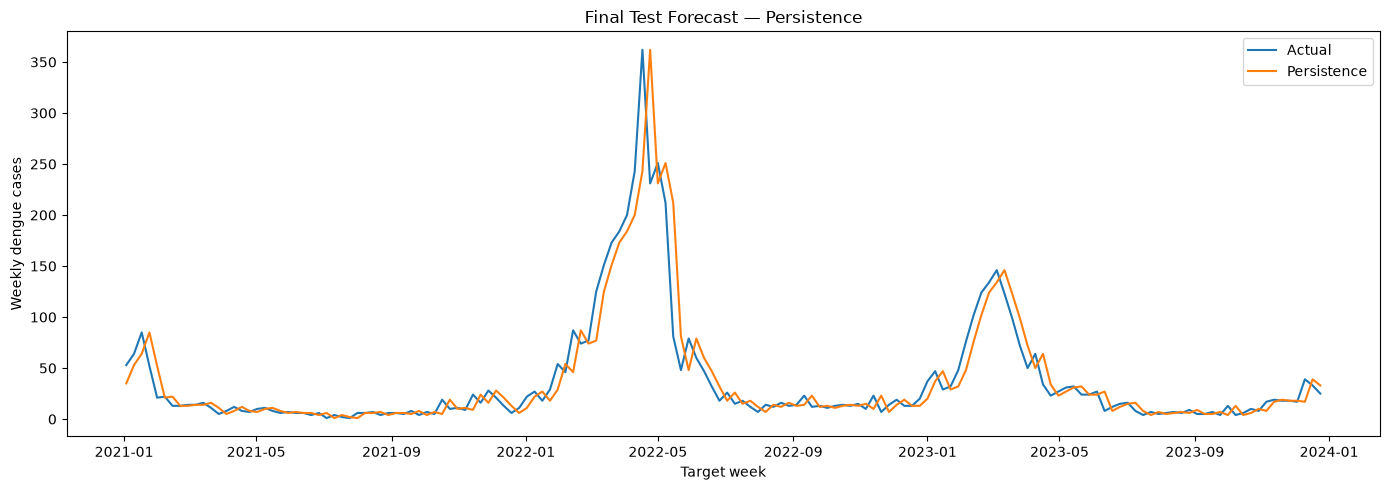

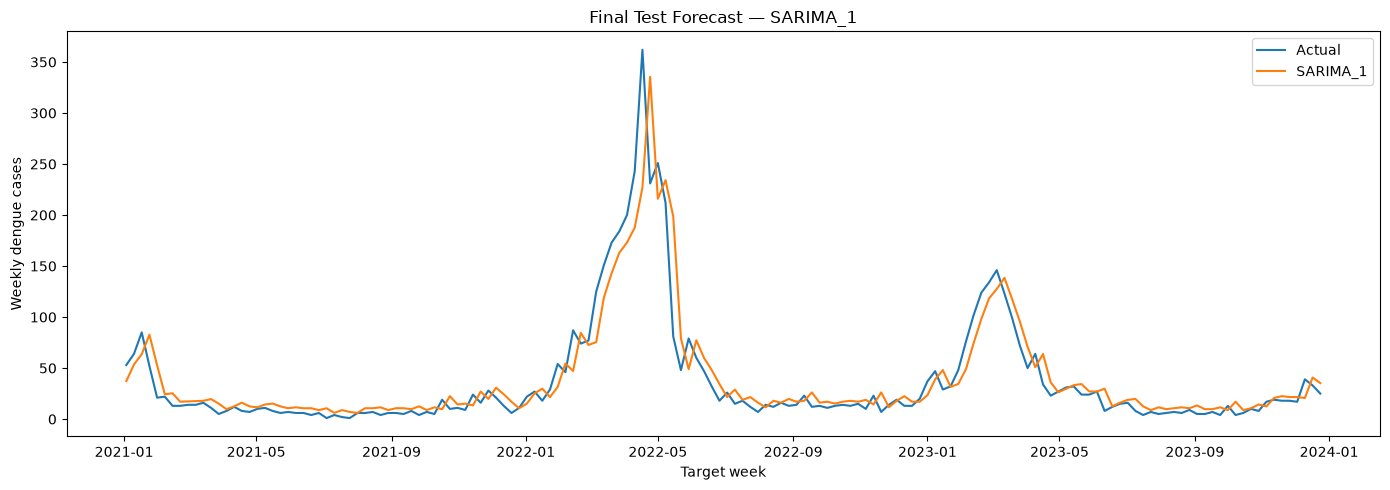

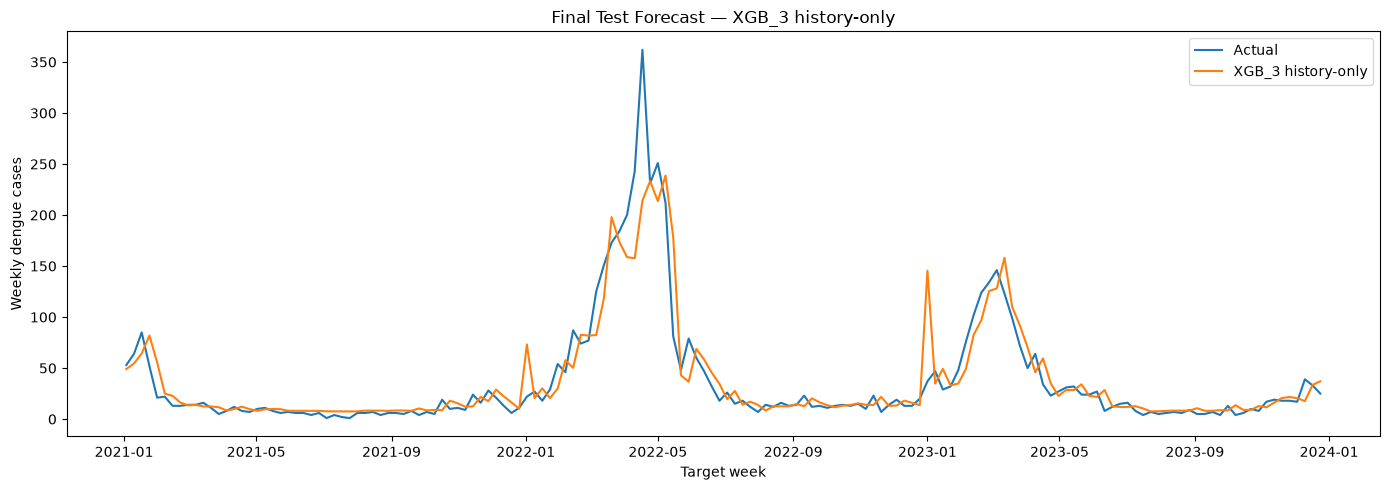

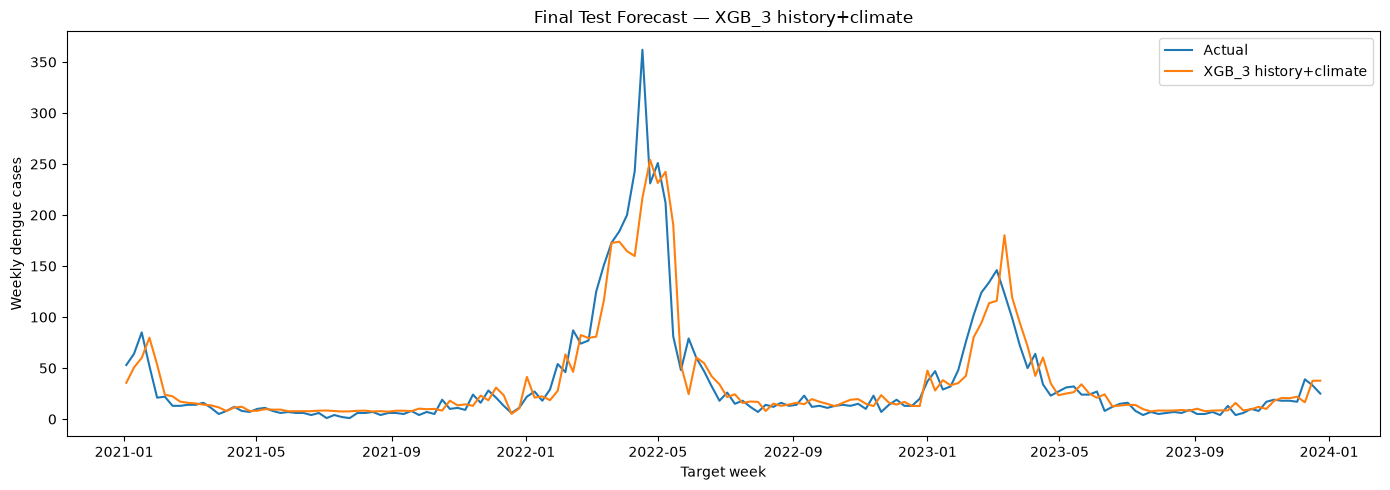

In [39]:
plot_models = [
    (
        "Persistence",
        persistence_test,
    ),
    (
        "SARIMA_1",
        sarima_test,
    ),
    (
        "XGB_3 history-only",
        xgb_history_test,
    ),
    (
        "XGB_3 history+climate",
        xgb_climate_test,
    ),
]

for model_name, prediction_df in plot_models:

    fig, ax = plt.subplots(
        figsize=(14, 5)
    )

    ax.plot(
        prediction_df["week_start_date"],
        prediction_df["dengue_cases"],
        label="Actual",
    )

    ax.plot(
        prediction_df["week_start_date"],
        prediction_df["prediction"],
        label=model_name,
    )

    ax.set_title(
        f"Final Test Forecast — {model_name}"
    )
    ax.set_xlabel("Target week")
    ax.set_ylabel("Weekly dengue cases")
    ax.legend()

    plt.tight_layout()
    plt.show()

## 14. Final XGBoost feature importance

Feature importance is reported for the climate-enhanced final XGBoost model to describe which predictors the fitted model uses.

It should not be interpreted causally.

In [40]:
xgb_final_importance = pd.DataFrame({
    "feature": CLIMATE_ENHANCED_FEATURES,
    "importance": (
        xgb_climate_model.feature_importances_
    ),
})

xgb_final_importance = (
    xgb_final_importance
    .sort_values(
        "importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

xgb_final_importance.head(20)

,feature,importance
0,dengue_cases_lag1,0.626431
1,week_sin,0.094436
2,precip_sum_mm_lag4,0.069243
3,temperature_c_mean_lag1,0.053738
4,wind_speed_ms_mean_lag12,0.035200
5,surface_pressure_hpa_mean_lag8,0.030174
6,wind_speed_ms_mean_prev4w_mean,0.024467
7,precip_sum_mm_prev4w_sum,0.015559
8,week_cos,0.010480
9,wind_speed_ms_mean_lag1,0.006412


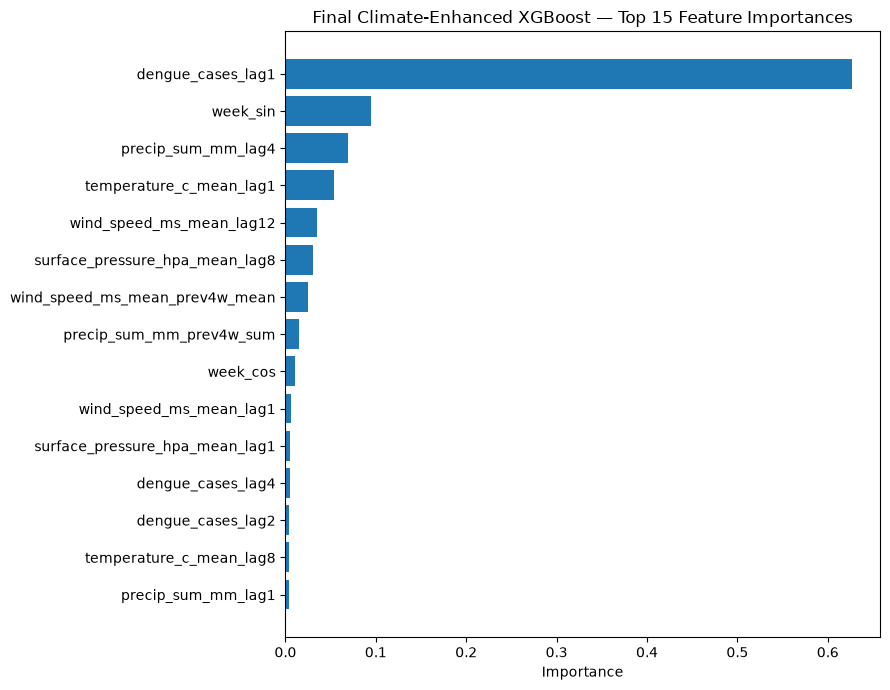

In [41]:
fig, ax = plt.subplots(
    figsize=(9, 7)
)

top_importance = (
    xgb_final_importance
    .head(15)
    .sort_values("importance")
)

ax.barh(
    top_importance["feature"],
    top_importance["importance"],
)

ax.set_title(
    "Final Climate-Enhanced XGBoost — Top 15 Feature Importances"
)
ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

### Interpretation — final XGBoost feature importance

The final climate-enhanced XGBoost remains dominated by recent dengue incidence.

`dengue_cases_lag1` accounts for approximately **62.6%** of total feature importance, making recent case burden by far the strongest predictor.

The most influential non-dengue features include:

- annual seasonal sine term: **9.4%**
- 4-week lagged precipitation: **6.9%**
- 1-week lagged temperature: **5.4%**
- 12-week lagged wind speed: **3.5%**
- 8-week lagged surface pressure: **3.0%**
- 4-week mean wind speed: **2.4%**
- previous 4-week precipitation accumulation: **1.6%**

This supports the broader project conclusion: recent dengue incidence supplies most of the one-week-ahead predictive signal, while meteorological variables provide smaller refinements.

Some environmental variables contribute very little or zero tree importance. They should **not** be removed and the model rerun now, because doing so after inspecting final test behaviour would compromise the holdout design. Their low importance should instead be documented as a finding and possible future refinement.

Tree importance is predictive rather than causal and does not establish that a variable directly drives dengue transmission.


### Interpretation — importance caveat

Feature importance describes how the fitted XGBoost model allocates predictive splits across variables. It does not show causal effects and should be interpreted alongside the paired performance comparison rather than used alone to claim that a climate variable improves forecasts.


## 15. Save final evaluation outputs

These outputs represent the final, frozen holdout evaluation.

In [42]:
final_comparison.to_csv(
    OUTPUT_DIR
    / "final_test_model_comparison.csv",
    index=False,
)

climate_final_comparison.to_csv(
    OUTPUT_DIR
    / "final_test_climate_increment.csv",
    index=False,
)

final_incidence_errors.to_csv(
    OUTPUT_DIR
    / "final_test_incidence_errors.csv",
    index=False,
)

xgb_final_importance.to_csv(
    OUTPUT_DIR
    / "final_xgb_climate_feature_importance.csv",
    index=False,
)

persistence_test[
    [
        "week_start_date",
        "dengue_cases",
        "prediction",
        "residual",
    ]
].to_csv(
    OUTPUT_DIR
    / "final_persistence_predictions.csv",
    index=False,
)

sarima_test[
    [
        "week_start_date",
        "dengue_cases",
        "prediction",
        "residual",
    ]
].to_csv(
    OUTPUT_DIR
    / "final_sarima_predictions.csv",
    index=False,
)

xgb_history_test[
    [
        "week_start_date",
        "dengue_cases",
        "prediction",
        "residual",
    ]
].to_csv(
    OUTPUT_DIR
    / "final_xgb_history_predictions.csv",
    index=False,
)

xgb_climate_test[
    [
        "week_start_date",
        "dengue_cases",
        "prediction",
        "residual",
    ]
].to_csv(
    OUTPUT_DIR
    / "final_xgb_climate_predictions.csv",
    index=False,
)

print(
    "Final holdout outputs saved to outputs/final/"
)

Final holdout outputs saved to outputs/final/


## 16. Final conclusions

The modelling phase is now complete. No further tuning or model changes should be made using the 2021–2023 test results.

### H1 — Do climate/environmental variables improve weekly dengue case prediction beyond historical dengue incidence?

**Final conclusion: supported, but with a modest and model-dependent effect.**

On the untouched test set, the frozen climate-enhanced XGBoost improves over the identical history-only XGBoost specification:

- MAE: **11.45 → 11.13** (**2.76% improvement**)
- RMSE: **22.35 → 21.22** (**5.05% improvement**)

The climate-enhanced model also has lower MAE during both the seven higher-incidence weeks and the remaining 149 weeks.

This final result supports incremental predictive value from environmental information. However, the broader development evidence remains mixed: climate improved Random Forest, slightly worsened XGBoost validation performance overall, and substantially worsened SARIMAX. The appropriate conclusion is therefore not that climate universally improves dengue prediction, but that **lagged environmental information can provide a small additional forecasting benefit when incorporated through an appropriate non-linear model**.

### H2 — Do machine-learning models outperform a traditional time-series model?

**Final conclusion: supported on the future holdout.**

The winning climate-enhanced XGBoost achieves:

- MAE **11.13**
- RMSE **21.22**
- R² **0.855**

compared with SARIMA_1:

- MAE **12.14**
- RMSE **21.67**
- R² **0.849**

XGBoost therefore outperforms the selected traditional model on all three final metrics, although the RMSE advantage is modest.

### Overall predictive conclusion

The strongest one-week-ahead forecast is the **climate-enhanced XGBoost model**, but its advantage over persistence is small on MAE:

- XGBoost + climate MAE: **11.13**
- Persistence MAE: **11.22**

This demonstrates that recent dengue incidence is the dominant source of short-horizon predictive information.

The final XGBoost feature importance reinforces this: `dengue_cases_lag1` accounts for approximately **62.6%** of model importance. Environmental variables such as lagged rainfall, temperature, wind and pressure provide smaller refinements.

The most defensible overall conclusion is:

> **One-week-ahead dengue incidence in Maynas is predicted primarily by recent dengue incidence, while lagged meteorological information provides a modest additional forecasting benefit when incorporated through a non-linear boosting model.**

### Limitations to report

The final interpretation should acknowledge:

- only 1,248 observed dengue weeks were available overall;
- the target is highly right-skewed and includes relatively few epidemic weeks;
- only seven final-test weeks met the descriptive high-incidence threshold;
- feature importance is predictive rather than causal;
- environmental effects were model-dependent;
- the study is specific to Maynas and may not generalise directly to other locations;
- the final winning model improves only slightly on persistence in MAE despite its greater complexity.
